
# Linear‐contrast t-test and confidence interval

Computes the linear‐contrast t-test and confidence interval either from raw data (lists/arrays of observations per group) or from summary stats (means, sizes, pooled MSE).



## **Hypothesis Testing for General Linear Contrasts**

We want to test whether a linear combination of the group means equals zero.

$$
H_0:\sum_{i=1}^k a_i\theta_i = 0
\qquad\text{vs.}\qquad
H_1:\sum_{i=1}^k a_i\theta_i \neq 0
$$

To test at significance level $ \alpha $:

Reject $H_0$ if

$$
\left|\frac{\sum_{i=1}^{k} a_i\overline{Y}_i}
{\sqrt{S_p^2\sum_{i=1}^{k}\frac{a_i^2}{n_i}}} \right|< t_{N-k,\alpha/2}
$$

---

## **Confidence Interval for the Contrast**

A $100(1-\alpha)%$ confidence interval for the linear contrast
$\sum_{i=1}^k a_i\theta_i$ is

$$
\sum_{i=1}^k a_i \overline{Y}_i \pm t_{N-k,\alpha/2}\sqrt{ S_p^2 \sum_{i=1}^{k} \frac{a_i^2}{n_i} }
$$

---

### **Notes**

* This is used in ANOVA after we determine that not all means are equal.
* The vector $(a = (a_1, \ldots, a_k))$ defines the **contrast** (e.g., difference between two means or comparison of averages of several groups).
* $(S_p^2)$is the pooled variance from the ANOVA model.
* $(t_{N-k,\alpha/2})$ uses ($N-k$) degrees of freedom because ANOVA estimates ($k$) means.

--

In [1]:
import numpy as np
from scipy import stats

def _pooled_mse_from_raw(groups):
    """
    groups: list of 1D arrays/lists, one per group
    Returns (means, ns, mse, N, k)
    """
    xs = [np.asarray(g, dtype=float) for g in groups]
    ns = np.array([len(g) for g in xs], dtype=int)
    if np.any(ns < 2):
        raise ValueError("Each group must have at least 2 observations.")
    means = np.array([g.mean() for g in xs], dtype=float)
    # Within-group (residual) sum of squares
    ssw = sum(((g - m) ** 2).sum() for g, m in zip(xs, means))
    N = ns.sum()
    k = len(xs)
    df = N - k
    mse = ssw / df
    return means, ns, mse, N, k

def _contrast_core(means, ns, mse, a, alpha=0.05):
    """
    means: array of group means (length k)
    ns: array of group sizes (length k)
    mse: pooled within-group variance (a.k.a. S_p^2 or MSE)
    a: array of contrast weights (length k)
    """
    means = np.asarray(means, dtype=float)
    ns = np.asarray(ns, dtype=float)
    a = np.asarray(a, dtype=float)

    if not (len(means) == len(ns) == len(a)):
        raise ValueError("means, ns, and a must have the same length (k groups).")

    N = int(ns.sum())
    k = len(ns)
    df = N - k

    est = float(np.dot(a, means))
    se = float(np.sqrt(mse * np.sum(a**2 / ns)))
    t_stat = est / se
    p_val = 2 * stats.t.sf(abs(t_stat), df)
    tcrit = stats.t.ppf(1 - alpha / 2, df)
    ci = (est - tcrit * se, est + tcrit * se)

    return {
        "estimate": est,
        "se": se,
        "t": t_stat,
        "df": df,
        "p_value_two_sided": p_val,
        f"{100*(1-alpha):.0f}%_CI": ci,
        "mse": mse
    }

def contrast_from_raw(groups, a, alpha=0.05):
    """
    Linear-contrast test/CI assuming equal variances across groups (ANOVA model).

    groups: list of 1D arrays/lists of observations per group [g1, g2, ..., gk]
    a: contrast weights (length k). Example: [1, -0.5, -0.5] tests
       mean(group1) - average(mean(group2), mean(group3)).
    """
    means, ns, mse, N, k = _pooled_mse_from_raw(groups)
    return _contrast_core(means, ns, mse, a, alpha=alpha)

def contrast_from_summary(means, ns, mse, a, alpha=0.05):
    """
    Same as contrast_from_raw, but you already have summary stats.

    means: array-like of group means
    ns: array-like of group sizes
    mse: pooled within-group variance (a.k.a. S_p^2 or MSE from ANOVA)
    a: contrast weights
    """
    return _contrast_core(means, ns, mse, a, alpha=alpha)


### Example1  — from raw data

In [2]:
# Three groups (toy data)
g1 = [9.2, 10.1, 10.5, 9.7, 10.3]
g2 = [8.8, 9.0, 9.3, 9.1, 9.2, 8.9]
g3 = [8.6, 8.7, 8.8, 8.5, 8.9]

# Contrast: treatment (g1) vs average of controls (g2, g3)
a = [1, -0.5, -0.5]

res = contrast_from_raw([g1, g2, g3], a, alpha=0.05)
res


{'estimate': 1.084999999999999,
 'se': 0.17384232466851646,
 't': 6.241287914602403,
 'df': 13,
 'p_value_two_sided': np.float64(3.0133439904768677e-05),
 '95%_CI': (np.float64(0.709436490619817), np.float64(1.4605635093801812)),
 'mse': np.float64(0.10361538461538475)}

### Example 2-from summary stats

In [3]:
means = [10.0, 9.05, 8.70]
ns    = [5, 6, 5]
mse   = 0.153  # e.g., the ANOVA MSE (pooled variance) you computed elsewhere
a     = [1, -0.5, -0.5]

res2 = contrast_from_summary(means, ns, mse, a, alpha=0.05)
res2

{'estimate': 1.125,
 'se': 0.2112463017427761,
 't': 5.325537018725447,
 'df': 13,
 'p_value_two_sided': np.float64(0.00013766928131427362),
 '95%_CI': (np.float64(0.6686301109216011), np.float64(1.581369889078399)),
 'mse': 0.153}

Contrast estimate = 1.085
SE = 0.174
t = 6.241, df=13
p-value = 0.0000
95.0% CI = (0.709, 1.461)


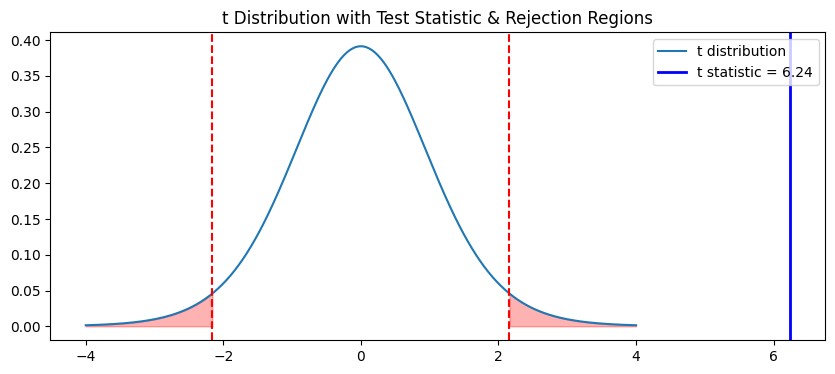

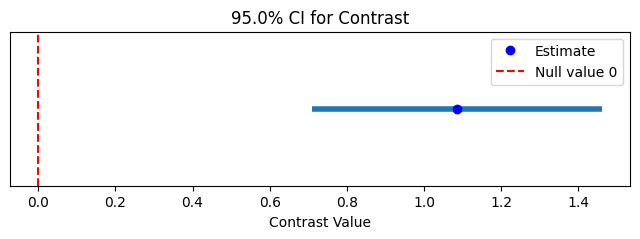

In [4]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# --- Example data ---
g1 = np.array([9.2, 10.1, 10.5, 9.7, 10.3])
g2 = np.array([8.8, 9.0, 9.3, 9.1, 9.2, 8.9])
g3 = np.array([8.6, 8.7, 8.8, 8.5, 8.9])

groups = [g1, g2, g3]
a = np.array([1, -0.5, -0.5])  # treatment vs average controls
alpha = 0.05

# --- Compute contrast statistics ---
means = np.array([g.mean() for g in groups])
ns = np.array([len(g) for g in groups])
N = ns.sum()
k = len(ns)
df = N - k

# pooled MSE
ssw = sum(((g - g.mean())**2).sum() for g in groups)
mse = ssw / df

est = np.dot(a, means)
se = np.sqrt(mse * np.sum(a**2 / ns))
t_stat = est / se
tcrit = stats.t.ppf(1 - alpha/2, df)
ci = (est - tcrit*se, est + tcrit*se)
p_val = 2 * stats.t.sf(abs(t_stat), df)

print(f"Contrast estimate = {est:.3f}")
print(f"SE = {se:.3f}")
print(f"t = {t_stat:.3f}, df={df}")
print(f"p-value = {p_val:.4f}")
print(f"{100*(1-alpha)}% CI = ({ci[0]:.3f}, {ci[1]:.3f})")

# --- Plot t distribution with test statistic ---
x = np.linspace(-4, 4, 400)
y = stats.t.pdf(x, df)

plt.figure(figsize=(10,4))

# Plot t density
plt.plot(x, y, label="t distribution")

# Shade rejection regions
x_fill_left = np.linspace(-4, -tcrit, 200)
x_fill_right = np.linspace(tcrit, 4, 200)
plt.fill_between(x_fill_left, stats.t.pdf(x_fill_left, df), alpha=0.3, color='red')
plt.fill_between(x_fill_right, stats.t.pdf(x_fill_right, df), alpha=0.3, color='red')
plt.axvline(tcrit, linestyle="--", color="red")
plt.axvline(-tcrit, linestyle="--", color="red")

# Plot test statistic
plt.axvline(t_stat, color="blue", linewidth=2, label=f"t statistic = {t_stat:.2f}")
plt.title("t Distribution with Test Statistic & Rejection Regions")
plt.legend()
plt.show()

# --- Plot CI on number line ---
plt.figure(figsize=(8,2))
plt.hlines(1, ci[0], ci[1], linewidth=4)
plt.plot(est, 1, 'bo', label="Estimate")
plt.axvline(0, linestyle="--", color="red", label="Null value 0")

plt.title(f"{100*(1-alpha)}% CI for Contrast")
plt.yticks([])
plt.xlabel("Contrast Value")
plt.legend()
plt.show()